In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
#load dataset
file_path="E:/Airbnb_Open_Data.csv"
df = pd.read_csv(file_path)
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

C:\Users\Dell\AppData\Local\Temp\ipykernel_6932\2178225831.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [5]:
df.iloc[:,24]

0         Clean up and treat the home the way you'd like...
1         Pet friendly but please confirm with me if the...
2         I encourage you to use my kitchen, cooking and...
3                                                       NaN
4         Please no smoking in the house, porch or on th...
                                ...                        
102594    No Smoking No Parties or Events of any kind Pl...
102595    House rules: Guests agree to the following ter...
102596                                                  NaN
102597                                                  NaN
102598                                                  NaN
Name: house_rules, Length: 102599, dtype: object

In [7]:
df = pd.read_csv(file_path, low_memory=False)


In [9]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [11]:
print(df.isnull().sum())

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [17]:
#convert last review to datetime to handle errors, coerce replaces values with nan instead of raisning error
df['last review']=pd.to_datetime(df['last review'], errors='coerce')
#fill missing values
df.fillna({'reviews per month':0,'last review':df['last review'].min()}, inplace=True)
#drop records with missing name or hostname
df.dropna(subset=['NAME', 'host name'], inplace=True)

In [19]:
print(df.head())


        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   
5  1004098         Large Cozy 1 BR Apartment In Midtown East  45498551794   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
4               verified    Lyndon           Manhattan   East Harlem   
5               verified  Michelle           Manhattan   Murray Hill   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

In [21]:
print(df.isnull())

           id   NAME  host id  host_identity_verified  host name  \
0       False  False    False                   False      False   
1       False  False    False                   False      False   
2       False  False    False                    True      False   
4       False  False    False                   False      False   
5       False  False    False                   False      False   
...       ...    ...      ...                     ...        ...   
102594  False  False    False                   False      False   
102595  False  False    False                   False      False   
102596  False  False    False                   False      False   
102597  False  False    False                   False      False   
102598  False  False    False                   False      False   

        neighbourhood group  neighbourhood    lat   long  country  ...  \
0                     False          False  False  False    False  ...   
1                     False        

In [23]:
print(df.isnull().sum())

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

In [27]:
#remove dollar signs and convert to float
df['price'] = df.['price'].replace('[\$,]','', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]','', regex=True).astype(float)

SyntaxError: invalid syntax (3122164874.py, line 2)

In [6]:
df.drop_duplicates(inplace=True)

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   NAME                            101808 non-null  object 
 2   host id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host name                       101654 non-null  object 
 5   neighbourhood group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   country                         101526 non-null  object 
 10  country code                    101927 non-null  object 
 11  instant_bookable                101953 non-null  object 
 12  cancellation_policy  

In [10]:
print(df.describe())

                 id       host id            lat           long  \
count  1.020580e+05  1.020580e+05  102050.000000  102050.000000   
mean   2.918438e+07  4.926738e+10      40.728097     -73.949652   
std    1.627173e+07  2.853742e+10       0.055852       0.049502   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.509286e+07  2.459924e+10      40.688730     -73.982580   
50%    2.918438e+07  4.912865e+10      40.722290     -73.954440   
75%    4.327590e+07  7.400619e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      101844.000000   101658.000000      101875.000000   
mean         2012.488090        8.126640          27.517948   
std             5.765838       30.616698          49.571744   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

<function matplotlib.pyplot.show(close=None, block=None)>

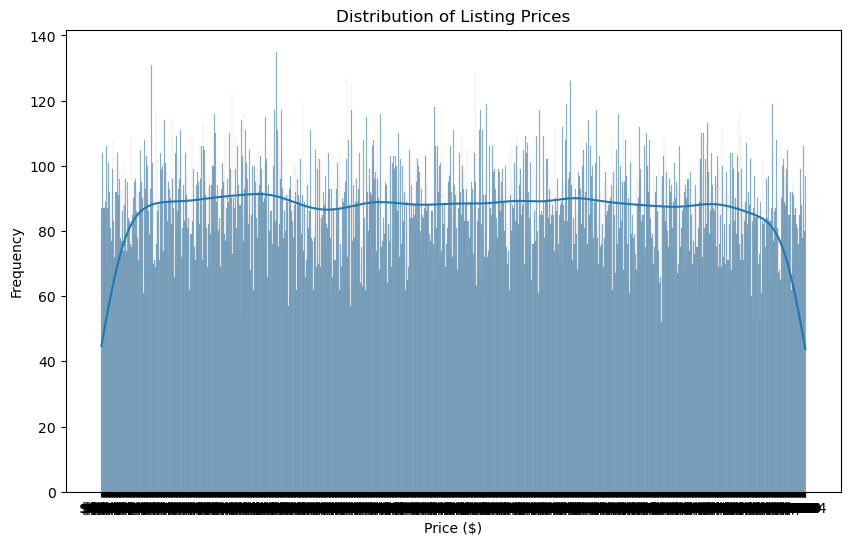

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=50, kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show

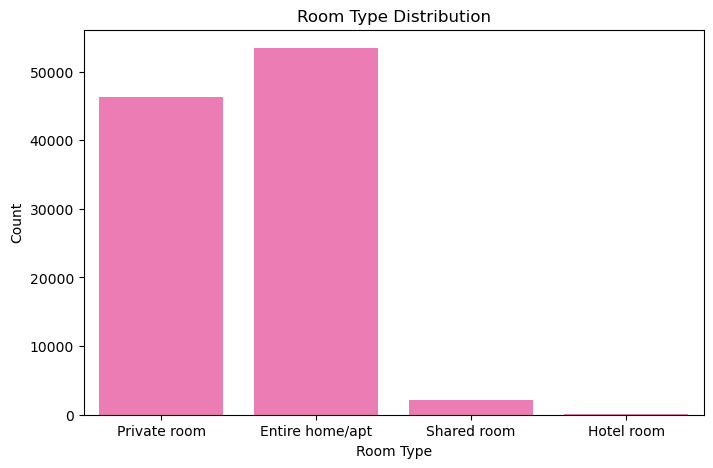

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='room type', data=df , color='hotpink')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()